## §1 为什么 SGD 不够

**Vanilla SGD**：$w_{t+1} = w_t - \eta g_t$

三大痛点：

1. **病态曲率**：峡谷地形（$x$ 方向平坦、$y$ 方向陡峭）→ 沿峡谷壁来回震荡、前进缓慢
2. **学习率一刀切**：稀疏特征（词 Embedding）需要大步长频繁更新，密集特征需要小步长稳定——统一 $\eta$ 不匹配
3. **没有历史信息**：每次只看瞬时梯度，噪声大（mini-batch 采样波动）

修正方向：**记忆历史**（动量族）与 **逐参数自适应**（RMS 族）。

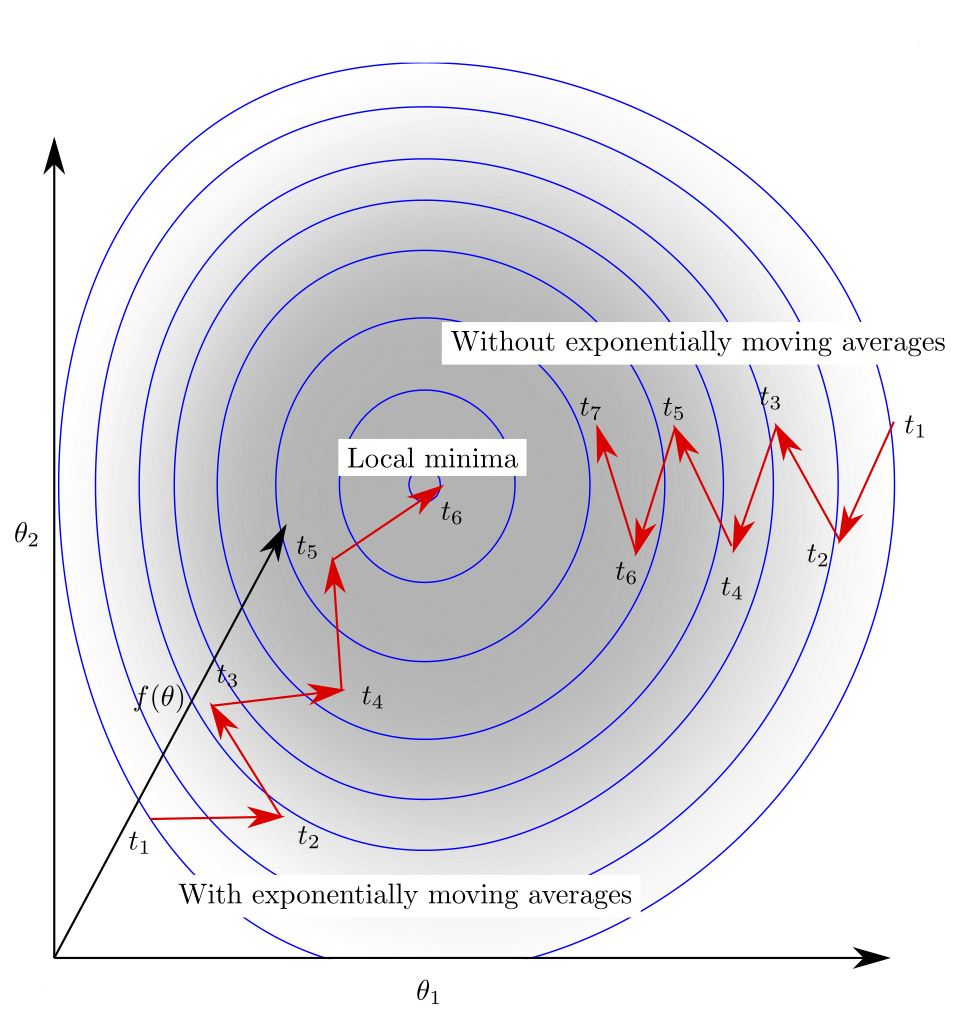

> 📷 带动量的梯度下降：积累历史梯度方向，加速收敛并抑制震荡
> *图源：Wikimedia Commons（开放授权）*


In [ ]:
import numpy as np

# ---------- 五种优化器，统一接口 update(g, params) ----------
class SGD:
    def __init__(self, lr=0.1):
        self.lr = lr
    def step(self, g, p, t):
        return p - self.lr * g

# 注意：每个参数形状不同，动量/统计量必须按形状分开存（同形状不同参数会共享——
# 工程实现按参数 id 注册状态，本演示每参数形状唯一，用 shape 作键足够）
class Momentum:
    """v = βv + g  ;  w -= lr*v"""
    def __init__(self, lr=0.1, beta=0.9):
        self.lr, self.beta = lr, beta
        self.vs = {}                        # {shape: v}
    def step(self, g, p, t):
        key = g.shape if hasattr(g, 'shape') else ()   # 兼容标量参数（float 无 .shape）
        v = self.vs.get(key)
        v = self.beta * v + g if v is not None else g
        self.vs[key] = v
        return p - self.lr * v

class AdaGrad:
    """累计梯度平方 G += g² ; w -= lr*g/sqrt(G+eps)"""
    def __init__(self, lr=0.01, eps=1e-8):
        self.lr, self.eps = lr, eps
        self.Gs = {}                        # {shape: G}
    def step(self, g, p, t):
        key = g.shape if hasattr(g, 'shape') else ()   # 兼容标量参数（float 无 .shape）
        G = self.Gs.get(key)
        G = g * g if G is None else G + g * g
        self.Gs[key] = G
        return p - self.lr * g / (np.sqrt(G) + self.eps)

class RMSProp:
    """指数滑动平均 E = βE + (1-β)g² ; w -= lr*g/sqrt(E+eps)"""
    def __init__(self, lr=0.01, beta=0.9, eps=1e-8):
        self.lr, self.beta, self.eps = lr, beta, eps
        self.Es = {}                        # {shape: E}
    def step(self, g, p, t):
        key = g.shape if hasattr(g, 'shape') else ()   # 兼容标量参数（float 无 .shape）
        E = self.Es.get(key)
        E = self.beta * E + (1 - self.beta) * g * g if E is not None else (1 - self.beta) * g * g
        self.Es[key] = E
        return p - self.lr * g / (np.sqrt(E) + self.eps)

class Adam:
    """m = β1 m + (1-β1)g ; v = β2 v + (1-β2)g² ; 偏差校正后更新"""
    def __init__(self, lr=0.001, beta1=0.9, beta2=0.999, eps=1e-8):
        self.lr, self.b1, self.b2, self.eps = lr, beta1, beta2, eps
        self.ms, self.vs = {}, {}           # {shape: m}, {shape: v}
    def step(self, g, p, t):
        key = g.shape if hasattr(g, 'shape') else ()   # 兼容标量参数（float 无 .shape）
        m = self.ms.get(key)
        m = self.b1 * m + (1 - self.b1) * g if m is not None else (1 - self.b1) * g
        v = self.vs.get(key)
        v = self.b2 * v + (1 - self.b2) * g * g if v is not None else (1 - self.b2) * g * g
        self.ms[key], self.vs[key] = m, v
        mhat = m / (1 - self.b1 ** (t + 1))     # 偏差校正（t 从 0 开始）
        vhat = v / (1 - self.b2 ** (t + 1))
        return p - self.lr * mhat / (np.sqrt(vhat) + self.eps)

# 自检：极简二次型 f(w) = w^2/2，梯度 = w，最优 w=0
for name, opt in [('SGD', SGD(0.3)), ('Momentum', Momentum(0.3)),
                  ('AdaGrad', AdaGrad(0.5)), ('RMSProp', RMSProp(0.5)), ('Adam', Adam(0.3))]:
    w = 2.0
    for t in range(5):
        w = opt.step(w, w, t)
    print(f'{name:9s} 5 步后 w = {w:.5f}（目标 0）')
print('\nAdam 偏差校正演示：t=0 时 mhat = g/(1-0.9) = 10g，避免首步被 1-β1 缩小')
adam = Adam(0.1)
print('  首步裸 m =', round(0.1 * 1.0, 4), ' 校正后 mhat =', round(1.0 / (1 - 0.9 ** 1), 4),
      '（早期校正让更新量恢复到 ~g 尺度）')

## §2 公式总表（面试背诵核心）

| 优化器 | 动量/统计量 | 更新 |
|--------|------------|------|
| SGD | — | $w \gets w - \eta g$ |
| Momentum | $v \gets \beta v + g$ | $w \gets w - \eta v$ |
| Nesterov | $v \gets \beta v + \nabla f(w-\eta\beta v)$ | $w \gets w - \eta v$ |
| AdaGrad | $G \gets G + g^2$ | $w \gets w - \frac{\eta}{\sqrt{G}+\epsilon} g$ |
| RMSProp | $E \gets \beta E + (1-\beta)g^2$ | $w \gets w - \frac{\eta}{\sqrt{E}+\epsilon} g$ |
| Adam | $m \gets \beta_1 m + (1-\beta_1)g$, $v \gets \beta_2 v + (1-\beta_2)g^2$ | $w \gets w - \eta \frac{\hat m}{\sqrt{\hat v}+\epsilon}$ |

**偏差校正**（Adam 早期时刻很关键）：

$$\hat m_t = \frac{m_t}{1 - \beta_1^t}, \quad \hat v_t = \frac{v_t}{1 - \beta_2^t}$$

**直觉**：Momentum 修**方向**（沿历史惯性滑行、抑制震荡）；Adagrad/RMSProp 修**步长**（大梯度方向自动减小、小梯度方向自动放大→处理稀疏特征）；Adam = 两者结合。

In [ ]:
# ---------- 实验 1：峡谷地形（病态曲率）上的收敛轨迹 ----------
# f(w) = w0^2 + 40*w1^2  →  w1 方向陡峭（梯度大 40 倍）
def canyon_grad(w):
    return np.array([2 * w[0], 80 * w[1]])

def run_on_canyon(opt_factory, steps=30, w0=np.array([1.0, 0.7])):
    w = w0.copy()
    pts = [w.copy()]
    opt = opt_factory()
    for t in range(steps):
        g = canyon_grad(w)
        w = opt.step(g, w, t)
        pts.append(w.copy())
    return np.array(pts)

import math
for name, fac in [('SGD', lambda: SGD(0.005)), ('Momentum', lambda: Momentum(0.005)),
                  ('RMSProp', lambda: RMSProp(0.1)), ('Adam', lambda: Adam(0.05))]:
    pts = run_on_canyon(fac)
    final = pts[-1]
    dist = math.sqrt((final ** 2).sum())
    # 中间输出：每 10 步打印一次位置
    trail = ' → '.join(f'({p[0]:.3f},{p[1]:.3f})' for p in pts[::10])
    print(f'{name:9s} 终点({final[0]:+.4f},{final[1]:+.4f}) 到原点距离={dist:.5f}')
    print(f'          轨迹: {trail}')
print('\n观察：峡谷陡轴(y)梯度大，SGD 会沿 y 震荡；Momentum 靠惯性穿越；'
      'RMSProp/Adam 用二阶矩把陡轴步长自动压小 —— 收敛快很多')

In [ ]:
# ---------- 实验 2：MLP 训练上的真实对比（同数据同初始，只换优化器） ----------
rng = np.random.default_rng(0)
X = rng.uniform(-2, 2, (200, 2))
Y = (X[:, 0] ** 2 - 3 * X[:, 1]).reshape(-1, 1)

def train_with_opt(opt, epochs=400, seed=0):
    r = np.random.default_rng(seed)
    W1 = r.normal(0, 1 / math.sqrt(2), (32, 2)); b1 = np.zeros(32)
    W2 = r.normal(0, 1 / math.sqrt(32), (1, 32)); b2 = np.zeros(1)
    losses = []
    for e in range(epochs):
        Z1 = X @ W1.T + b1; H = np.maximum(Z1, 0)
        Yhat = H @ W2.T + b2
        loss = np.mean((Yhat - Y) ** 2)
        losses.append(loss)
        dL = 2 * (Yhat - Y) / len(Y)
        gW2 = dL.T @ H; gb2 = dL.sum(0)
        dH = dL @ W2 * (Z1 > 0)
        gW1 = dH.T @ X; gb1 = dH.sum(0)
        W2 = opt.step(gW2, W2, e); b2 = opt.step(gb2, b2, e)
        W1 = opt.step(gW1, W1, e); b1 = opt.step(gb1, b1, e)
    return losses

opts = [('SGD', SGD(lr=0.1)), ('Momentum', Momentum(lr=0.1, beta=0.9)),
        ('AdaGrad', AdaGrad(lr=0.05)), ('RMSProp', RMSProp(lr=0.005)),
        ('Adam', Adam(lr=0.01))]
print('epoch | ' + ' | '.join(f'{n:>8s}' for n, _ in opts))
all_loss = {n: train_with_opt(o) for n, o in opts}
for e in [0, 10, 50, 150, 399]:
    print(f'{e:5d} | ' + ' | '.join(f'{all_loss[n][e]:8.4f}' for n, _ in opts))
print('\n结论：Momentum/Adam 前期下降快；AdaGrad 因累计 G 单调增大后期步长过小；'
      'Adam 综合最优（默认 lr=0.001 时更稳）')

## §3 超参与工程建议（必背）

| 优化器 | 默认 lr | 关键超参 | 适用场景 |
|--------|--------|----------|----------|
| SGD | 0.01~0.1 | lr 调度（warmup+decay） | 大规模 CV（配合 BN） |
| Momentum | 0.01~0.1 | $\beta=0.9$ | SGD 增强版 |
| AdaGrad | 0.01 | — | 稀疏特征（词向量） |
| RMSProp | 0.001 | $\beta=0.9$ | RNN（Hinton 原始） |
| Adam | 0.001 | $\beta_1=0.9,\ \beta_2=0.999$ | 默认首选（NLP/RL/生成） |

**Adam 的隐患与 AdamW**：L2 正则与 Adam 的自适应步长耦合（权重大→梯度大→步长小→正则被稀释）；AdamW 把**权重衰减与梯度解耦**：

$$\text{AdamW: } w \gets w - \eta \left( \frac{\hat m}{\sqrt{\hat v}+\epsilon} + \lambda w \right)$$

## §4 常见 bug 与边界（面试踩坑区）

- **状态量跨参数共享**：m/v/E 必须**逐参数**维护（每个权重张量一份），写成全局变量会串
- **首步 None 判断**：`v = beta*v + g if v is not None else g`——不判 None 会 `beta*(None)` 报错
- **偏差校正遗漏**：t 从 0 计，`1 - beta**(t+1)`；忘校正会导致头几百步更新量异常小
- **lr 忘调度**：SGD 不用学习率衰减在深谷末端会震荡不收敛
- **AdaGrad 后期停滞**：G 单调增大（等价于步长 -> 0），长训练要换 RMSProp/Adam
- **eps 位置**：`1/(sqrt(G)+eps)` 不是 `1/sqrt(G+eps)`——数值性质不同
- **与 numpy 混用**：`p - lr*g` 返回新数组，不 in-place 时参数对象要接收返回值

## §5 面试追问与扩展（加分项）

### 5.1 Adam vs SGD 最终精度

经验：Adam 前期快、对超参不敏感；但某些 CV 任务 SGD+Momentum（带调度）最终泛化更好（平坦极小值假说）。NLP 主流仍 AdamW。

### 5.2 为什么 RNN 常用 RMSProp/Adam

RNN 梯度尺度跨时间步变化剧烈（梯度爆炸/消失），自适应步长逐元素缩放能稳住训练。

### 5.3 学习率调度

warmup（线性升到峰值）→ decay（余弦/线性/指数）：防止早期大步长破坏预训练权值，后期小步长精细收敛。

### 5.4 变体

AdamW（解耦权重衰减）、NAdam（Adam+Nesterov）、LAMB（大 batch 自适应）、Adafactor（内存省内存，T5 用）。

## §6 自测清单（L1 必会 / L2 进阶 / L3 挑战）

### L1 必会（10 问）

- [ ] 1. 写出 Momentum 两条公式
- [ ] 2. 写出 AdaGrad / RMSProp 公式及区别
- [ ] 3. 写出 Adam 四条公式（含偏差校正）
- [ ] 4. 手写 SGD/Momentum（numpy）
- [ ] 5. 手写 AdaGrad/RMSProp/Adam
- [ ] 6. 解释动量为什么抑制震荡
- [ ] 7. 解释自适应步长为什么利稀疏特征
- [ ] 8. 默认学习率：SGD/Adam
- [ ] 9. 手写峡谷实验并输出轨迹
- [ ] 10. Adam 偏差校正在早期的作用

### L2 进阶（10 问）

- [ ] 11. Nesterov 与 Momentum 区别（看梯度位置）
- [ ] 12. 手写不同优化器 MLP 训练对比表
- [ ] 13. 推导 AdaGrad 步长随时间衰减
- [ ] 14. 手写 AdamW（解耦权重衰减）
- [ ] 15. 手写指数移动平均的偏差校正公式推导
- [ ] 16. 学习率 warmup/decay 手写
- [ ] 17. 解释 RMSProp 为什么适合 RNN
- [ ] 18. 手写带梯度的 batch 方差实验（SGD vs 全量）
- [ ] 19. Adam 的 m 与 v 初始化对早期步的影响实验
- [ ] 20. 手写 NAdam（Adam 嵌套 Nesterov）

### L3 挑战（5 问）

- [ ] 21. 推导 Adam 收敛性证明框架（Reddi 2019 修正）
- [ ] 22. LAMB 大 batch 自适应推导
- [ ] 23. Adafactor 内存优化（分解二阶矩）
- [ ] 24. SGD 平坦极小值 vs Adam 尖锐极小值实验
- [ ] 25. 手写 Lookahead/RAdam 变体

### 自测要点

- 10 分钟内盲写：Adam（含偏差校正）
- 白板默写优化器公式总表
- 讲清 Momentum vs 自适应 各解决什么问题

## 附录：参考与下节预告

- Kingma & Ba 2015：Adam 原论文
- CS231n 优化器讲义（斯坦福）

### 下节预告：模型笔记 4 — RNN 与 LSTM（门控机制手写 + 梯度消失分析）

> 💡 本笔记验收：`03-深度学习/README.md` 验收清单「优化器对比必含」打勾。